<a href="https://colab.research.google.com/github/krishnabhambore/Movie-Rating-Prediction/blob/main/Movie_Rating_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adrianmcmahon/imdb-india-movies")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-india-movies' dataset.
Path to dataset files: /kaggle/input/imdb-india-movies


In [14]:
import os
import pandas as pd

print(os.listdir(path))
df = pd.read_csv(os.path.join(path, os.listdir(path)[0]), encoding="ISO-8859-1")
print(df.shape)
df.head()

['IMDb Movies India.csv']
(15509, 10)


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [15]:
df.info()
print()
print(df.isnull().sum())
print()
print(df["Rating"].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

count    7919.000000
mean        5.841621
std         1.381777
min         1.100000
25%         4.900000
50%         6.000000
75%         6.800000
max        10.000000
Name: Rating, dtyp

In [16]:
import os
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("adrianmcmahon/imdb-india-movies")
df = pd.read_csv(os.path.join(path, "IMDb Movies India.csv"), encoding="ISO-8859-1")

df.info()
print()
print(df.isnull().sum())
print()
print(df["Rating"].describe())

Using Colab cache for faster access to the 'imdb-india-movies' dataset.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

count    7919.000000
mean        5.841621
std         1.381777
min         1.100000
25%         4.900000
50%      

In [17]:
# 1. Keep only movies that have a rating
df = df.dropna(subset=["Rating"]).copy()

# 2. Convert text columns into numbers
df["Year"] = pd.to_numeric(df["Year"].astype(str).str.extract(r"(\d{4})")[0], errors="coerce")
df["Duration"] = pd.to_numeric(df["Duration"].astype(str).str.extract(r"(\d+)")[0], errors="coerce")
df["Votes"] = pd.to_numeric(df["Votes"].astype(str).str.replace(",", "", regex=False), errors="coerce")

# 3. Fill missing text values
df["Genre"] = df["Genre"].fillna("Unknown")
for c in ["Director", "Actor 1", "Actor 2", "Actor 3"]:
    df[c] = df[c].fillna("Unknown")

# 4. Check the result
print(df.shape)
print()
print(df.isnull().sum())
print()
print(df.dtypes)

(7919, 10)

Name           0
Year           0
Duration    2068
Genre          0
Rating         0
Votes          0
Director       0
Actor 1        0
Actor 2        0
Actor 3        0
dtype: int64

Name         object
Year          int64
Duration    float64
Genre        object
Rating      float64
Votes         int64
Director     object
Actor 1      object
Actor 2      object
Actor 3      object
dtype: object


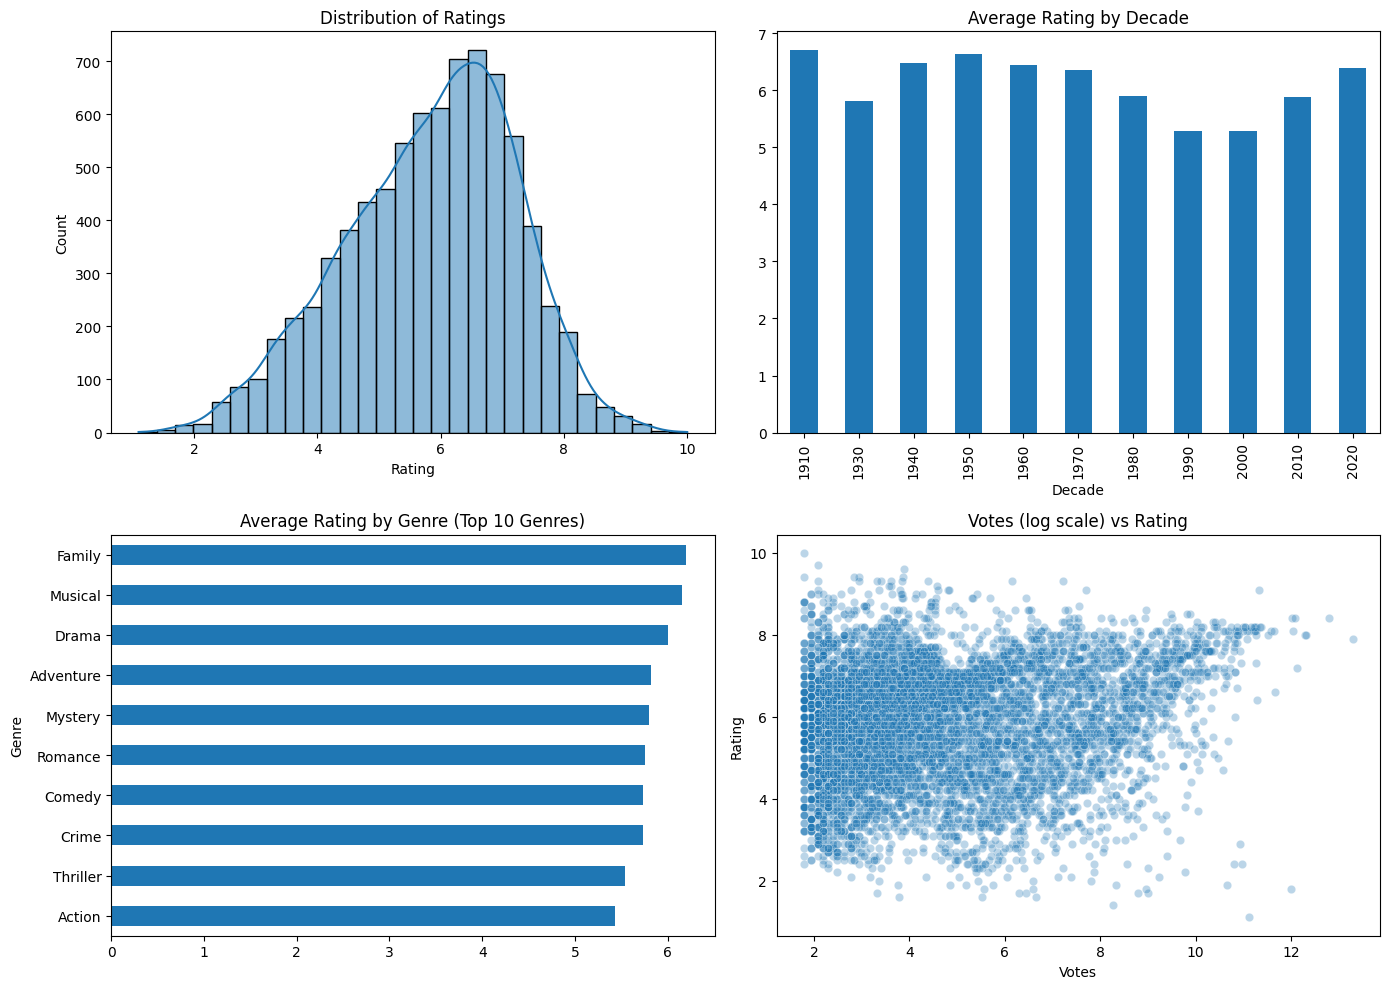

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. How are ratings distributed?
sns.histplot(df["Rating"], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Ratings")

# 2. Average rating by decade
df.groupby((df["Year"] // 10) * 10)["Rating"].mean().plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Average Rating by Decade")
axes[0, 1].set_xlabel("Decade")

# 3. Average rating for the 10 most common genres
genres = df.assign(Genre=df["Genre"].str.split(", ")).explode("Genre")
top10 = genres["Genre"].value_counts().head(10).index
genres[genres["Genre"].isin(top10)].groupby("Genre")["Rating"].mean().sort_values().plot(kind="barh", ax=axes[1, 0])
axes[1, 0].set_title("Average Rating by Genre (Top 10 Genres)")

# 4. Do more-voted movies get higher ratings?
sns.scatterplot(x=np.log1p(df["Votes"]), y=df["Rating"], alpha=0.3, ax=axes[1, 1])
axes[1, 1].set_title("Votes (log scale) vs Rating")

plt.tight_layout()
plt.show()

In [19]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Split FIRST, so the test movies stay completely unseen
train, test = train_test_split(df, test_size=0.2, random_state=42)
y_train, y_test = train["Rating"], test["Rating"]

# 2. Helper functions: replace a name with the average rating of that name
def smoothed_means(cat, y, prior, m=5):
    g = pd.DataFrame({"c": cat.values, "y": y.values}).groupby("c")["y"].agg(["sum", "count"])
    return (g["sum"] + prior * m) / (g["count"] + m)

def encode(train_col, y_train, test_col):
    prior = y_train.mean()
    oof = pd.Series(prior, index=train_col.index, dtype=float)
    for tr, va in KFold(5, shuffle=True, random_state=42).split(train_col):
        mapping = smoothed_means(train_col.iloc[tr], y_train.iloc[tr], prior)
        oof.iloc[va] = train_col.iloc[va].map(mapping).fillna(prior).values
    full = smoothed_means(train_col, y_train, prior)
    return oof, test_col.map(full).fillna(prior)

# 3. Build the features
X_train = pd.DataFrame(index=train.index)
X_test = pd.DataFrame(index=test.index)

for col in ["Year", "Duration"]:
    X_train[col], X_test[col] = train[col], test[col]
X_train["log_votes"], X_test["log_votes"] = np.log1p(train["Votes"]), np.log1p(test["Votes"])

g_train = train["Genre"].str.get_dummies(sep=", ")
top_genres = g_train.sum().nlargest(20).index
g_test = test["Genre"].str.get_dummies(sep=", ").reindex(columns=top_genres, fill_value=0)
X_train = X_train.join(g_train[top_genres].add_prefix("genre_"))
X_test = X_test.join(g_test.add_prefix("genre_"))

people = ["Director", "Actor 1", "Actor 2", "Actor 3"]
for col in people:
    X_train[col + "_score"], X_test[col + "_score"] = encode(train[col], y_train, test[col])
actor_cols = [c + "_score" for c in people[1:]]
X_train["actors_avg_score"] = X_train[actor_cols].mean(axis=1)
X_test["actors_avg_score"] = X_test[actor_cols].mean(axis=1)

imputer = SimpleImputer(strategy="median")   # fills the missing Duration values
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)
print("Features:", X_train.shape[1], "| Train:", len(X_train), "| Test:", len(X_test))

# 4. Train the models and compare
def score(name, pred):
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    print(f"{name:<22} RMSE={rmse:.3f}  MAE={mean_absolute_error(y_test, pred):.3f}  R2={r2_score(y_test, pred):.3f}")

score("Baseline (average)", np.full(len(y_test), y_train.mean()))

rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=3, n_jobs=-1, random_state=42).fit(X_train, y_train)
score("Random Forest", rf.predict(X_test))

hgb = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, random_state=42).fit(X_train, y_train)
score("Gradient Boosting", hgb.predict(X_test))

# 5. Which features matter most?
print()
print(pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10).round(3))

Features: 28 | Train: 6335 | Test: 1584
Baseline (average)     RMSE=1.365  MAE=1.107  R2=-0.002
Random Forest          RMSE=1.048  MAE=0.793  R2=0.409
Gradient Boosting      RMSE=1.027  MAE=0.773  R2=0.433

actors_avg_score     0.222
log_votes            0.190
Year                 0.152
Director_score       0.117
Duration             0.066
Actor 1_score        0.056
Actor 3_score        0.045
Actor 2_score        0.043
genre_Documentary    0.020
genre_Drama          0.017
dtype: float64


GB without votes       RMSE=1.121  MAE=0.863  R2=0.324


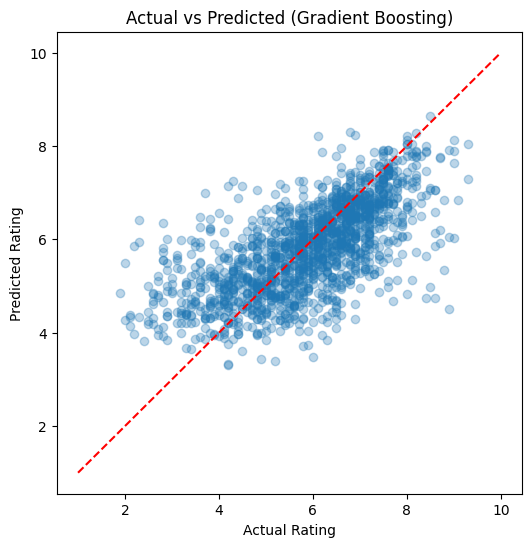

In [20]:
# A. Does the model still work without Votes? (a "pre-release" model)
X_tr_nv = X_train.drop(columns="log_votes")
X_te_nv = X_test.drop(columns="log_votes")
hgb_nv = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, random_state=42).fit(X_tr_nv, y_train)
score("GB without votes", hgb_nv.predict(X_te_nv))

# B. Actual vs predicted ratings for the best model
pred = hgb.predict(X_test)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, alpha=0.3)
plt.plot([1, 10], [1, 10], "r--")   # perfect predictions would fall on this line
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted (Gradient Boosting)")
plt.show()

In [21]:
X_tr_nv = X_train.drop(columns="log_votes")
X_te_nv = X_test.drop(columns="log_votes")
hgb_nv = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, random_state=42).fit(X_tr_nv, y_train)
score("GB without votes", hgb_nv.predict(X_te_nv))

GB without votes       RMSE=1.121  MAE=0.863  R2=0.324


## Conclusion

**Goal:** Predict the rating of an Indian movie from its genre, director, actors,
year, duration and votes, using regression.

**Data:** IMDb Movies India dataset. Of 15,509 movies, 7,919 had a rating and were
used for modelling (80% train / 20% test).

**Approach:** Cleaned Year, Duration and Votes into numbers, converted genres to
multi-hot columns, and replaced each director and actor with their average
movie rating (calculated on training data only, to avoid data leakage).
Compared a baseline against Random Forest and Gradient Boosting.

**Results:**

| Model | RMSE | MAE | R² |
|---|---|---|---|
| Baseline (mean rating) | 1.365 | 1.107 | -0.002 |
| Random Forest | 1.048 | 0.793 | 0.409 |
| Gradient Boosting | 1.027 | 0.773 | 0.433 |
| Gradient Boosting (no votes) | 1.121 | 0.863 | 0.324 |

Gradient Boosting performed best, with predictions off by about 0.77 rating
points on average.

**What influences ratings:** The strongest factors were the average rating of a
movie's cast, the number of votes, the release year and the director. Genre had
the smallest effect.

**Limitations:**
- Votes are only known after release, so the model without votes (R² 0.32) is the
  realistic "pre-release" version.
- The model predicts toward the middle: very low and very high ratings are
  under-predicted.
- Newer directors and actors have little history, so their scores are less reliable.
- Plot, budget and marketing are not in the data and would likely improve accuracy.

**Future improvements:** Add more features (budget, release season, plot text),
tune hyperparameters, and try other models such as XGBoost or LightGBM.